# Inspect a saved World and build a graph Scenario

Load any `world.json` artifact and walk every inspection surface. Then derive a
graph-mode `Scenario` from it using `world_to_graph`.

**Before you click "Run All":** This notebook targets an *already-saved* world so
it never triggers an LLM call. The demo uses the offline fixture produced by
`example_llm_world_offline.py` (6-item fashion catalog, no OpenAI key required).

See `notebooks/00-build-or-load-world.ipynb` (quickstart 3-node chain) and
`notebooks/02-inspect-scenario.ipynb` (full scenario inspection with `nodes_df` / `edges_df`).

In [1]:
%load_ext autoreload
%autoreload 2

import os
from dataclasses import replace
from pathlib import Path

while not (Path.cwd() / 'pyproject.toml').exists():
    os.chdir('..')

import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

from src.llm.world_builder import World
import matplotlib
%matplotlib inline


## Load a saved World

Point `WORLD_PATH` at any `world.json` produced by `WorldBuilder.build()` +
`World.to_json()` or the committed offline fixture.

In [2]:
WORLD_PATH = Path('notebooks/fixtures/world_fashion_retail_offline.json')

world = World.from_json(WORLD_PATH)
print(f'Loaded world: {len(world.catalog)} catalog items, '
      f'{len(world.store_templates)} store templates')

Loaded world: 6 catalog items, 2 store templates


### Meta — provenance

Records who built this world: archetype, item count, model name, builder
version, and build timestamp.

In [3]:
world.meta_df()

,archetype,n_items,model,builder_version,built_at
0,fashion_retail,6,None,1,2026-05-09T17:57:39.889742+00:00


### Market — demand and seasonality parameters

In [4]:
world.market_df()

,cycle_len,cycle_amp,init_demand,init_supply,peak_factor,off_factor,season_months,regions,correlation,trend_update_interval,min_value,max_value,stage_multipliers,price_elasticity,promo_multiplier,demand_factor_min,supply_factor_min,cross_inv_lo,cross_inv_hi,cross_factor_range,trend,demand_shock,supply_shock,base_demand
0,365,0.001,1.2,1.2,1.3,0.6,"{'spring/summer': [3, 4, 5, 6, 7, 8], 'fall/wi...",[US],0.7,20,0.2,2.0,"{'introduction': 0.7, 'growth': 1.5, 'maturity...",-1.4,1.0,0.1,0.01,0.3,0.7,"(0.3, 1.6)",Constant(value=1.0),"Normal(mean=0.0, std=0.01, clip=None)","Normal(mean=0.0, std=0.01, clip=None)","Uniform(low=2, high=8)"


### Store templates — retained for world authoring

Store templates survive in the `World` artifact as authoring inputs even after
the graph migration. `world_to_graph` (below) synthesises graph topology from
them, so the LLM-authored capacity / balance / region information is preserved.

In [5]:
world.store_templates_df().set_index('id')

,region,capacity,init_balance,init_stock_pct,delivery_lag,holding_rate,order_fee,init_active_count,init_active_products,init_freshness
id,,,,,,,,,,
flagship,US,500.0,20000.0,0.5,1.0,0.010,20.0,6,None,baseline
standard,US,200.0,10000.0,0.4,2.0,0.005,10.0,4,None,baseline


### Catalog — items for sale

One row per SKU. `freshness_alpha` and `freshness_decay` govern the hype-curve
multiplier applied inside `DemandSinkNode.demand_target`. `stage_change_probs`
controls lifecycle-stage transition rates.

In [6]:
world.catalog_df()

,product_id,name,category,base_price,unit_cost,margin,seasonality,freshness_alpha,freshness_decay,init_stage,stage_change_probs,init_stock_share,related_products
0,P0000,Linen Shirt,Apparel,60.0,24.0,36.0,spring/summer,0.20,30.0,None,None,None,[]
1,P0001,Wool Coat,Apparel,220.0,110.0,110.0,fall/winter,0.30,40.0,None,None,None,[]
2,P0002,Denim Jeans,Apparel,80.0,32.0,48.0,all_season,0.00,20.0,None,None,None,"[(Leather Belt, 0.6)]"
3,P0003,Leather Belt,Accessories,45.0,18.0,27.0,all_season,0.00,20.0,None,None,None,"[(Denim Jeans, 0.6)]"
4,P0004,Silk Scarf,Accessories,70.0,28.0,42.0,fall/winter,0.25,35.0,None,None,None,[]
5,P0005,Running Sneakers,Footwear,110.0,50.0,60.0,all_season,0.15,25.0,None,None,None,[]


## Synthesise a graph topology with `world_to_graph`

`world_to_graph(world, *, sink_density)` converts the `store_templates` dict
into a set of `(nodes, edges)` ready for a graph-mode `Scenario`. Each template
becomes a 3-tier sub-graph:

```
FactoryNode(s) → IntermediateNode (shop) → DemandSinkNode × K products
```

`sink_density` controls the fraction of catalog products each sink covers
(default 1.0 = one sink per catalog product per shop).

In [7]:
from src.sim.world import world_to_graph
from src.sim.scenario import (
    DisruptionParams,
    ItemLifecycleParams,
    MarketParams,
    Scenario,
)
from datetime import datetime

topology = world_to_graph(world, sink_density=1.0)
nodes = topology["node_instances"]
edges = topology["edges"]
print(f'Generated {len(nodes)} nodes and {len(edges)} edges')
node_types = [type(ni.node).__name__ for ni in nodes]
from collections import Counter
print('Node type counts:', dict(Counter(node_types)))

Generated 26 nodes and 24 edges
Node type counts: {'IntermediateNode': 2, 'FactoryNode': 12, 'DemandSinkNode': 12}


In [8]:
from src.sim.distributions import Constant, Normal

LIFECYCLE_STAGES = ['introduction', 'growth', 'maturity', 'decline', 'dead']

scenario = Scenario(
    catalog=world.catalog,
    market=world.market,
    disruption=DisruptionParams(
        event_prob=0.02, types=['natural_disaster'], regions=world.market.regions,
        severity=Constant(0.05), duration=Constant(2),
    ),
    item_lifecycle=ItemLifecycleParams(
        stages=LIFECYCLE_STAGES, init_stage='maturity',
        default_stage_change_probs={s: 0.0 for s in LIFECYCLE_STAGES},
    ),
    stores=[],
    nodes=nodes,
    edges=edges,
    n_steps=20,
    start_date=datetime(2024, 1, 1),
    world_seed=99,
)

print(f'Scenario: {len(scenario.nodes)} nodes, {len(scenario.edges)} edges')
print(f'is_graph: {scenario.is_graph}')

Scenario: 26 nodes, 24 edges
is_graph: True


## Inspect the graph scenario

`Scenario.nodes_df()` and `Scenario.edges_df()` are the canonical inspection views
for graph-mode scenarios — analogous to `catalog_df()` and `market_df()`.

In [9]:
scenario.nodes_df()

,node_id,node_type,region,init_seed,policy_class
0,flagship-shop,IntermediateNode,US,768017273,NaN
1,flagship-factory-P0000,FactoryNode,US,782478688,StaticFactoryPolicy
2,flagship-factory-P0001,FactoryNode,US,399150727,StaticFactoryPolicy
3,flagship-factory-P0002,FactoryNode,US,1457607270,StaticFactoryPolicy
4,flagship-factory-P0003,FactoryNode,US,1693388421,StaticFactoryPolicy
5,flagship-factory-P0004,FactoryNode,US,1287849544,StaticFactoryPolicy
6,flagship-factory-P0005,FactoryNode,US,2075098435,StaticFactoryPolicy
7,flagship-sink-P0000,DemandSinkNode,US,525967317,NaN
8,flagship-sink-P0001,DemandSinkNode,US,460713922,NaN
9,flagship-sink-P0002,DemandSinkNode,US,1409875060,NaN


In [10]:
scenario.edges_df()

,supplier_id,buyer_id,default_lead_time
0,flagship-factory-P0000,flagship-shop,1
1,flagship-factory-P0001,flagship-shop,1
2,flagship-factory-P0002,flagship-shop,1
3,flagship-factory-P0003,flagship-shop,1
4,flagship-factory-P0004,flagship-shop,1
5,flagship-factory-P0005,flagship-shop,1
6,flagship-shop,flagship-sink-P0000,1
7,flagship-shop,flagship-sink-P0001,1
8,flagship-shop,flagship-sink-P0002,1
9,flagship-shop,flagship-sink-P0003,1


## Run the scenario and inspect the run log

In [11]:
from src.sim.runner import Runner

run_log = Runner(scenario).run()
print('Run log keys:', list(run_log.keys()))
print(f'ticks logged: {len(run_log["ticks"])}')

Run log keys: ['n_steps', 'ticks', 'global']
ticks logged: 20


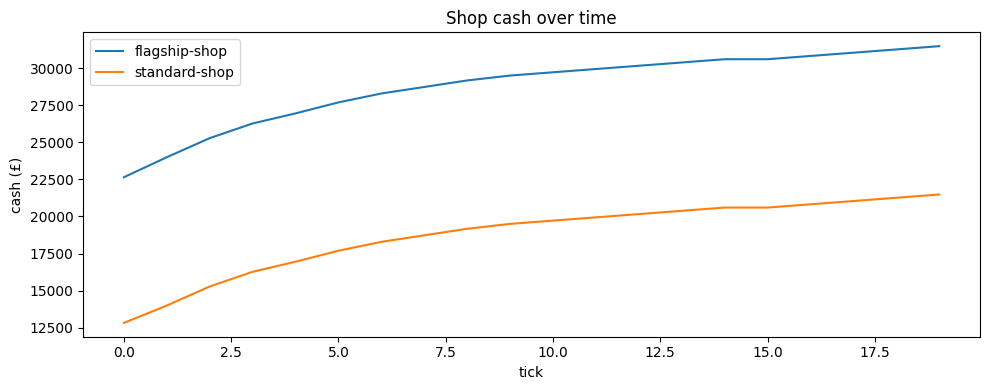

In [12]:
import matplotlib.pyplot as plt

# Plot per-tick cash for all intermediate nodes
from src.sim.node import IntermediateNode

shop_ids = [ni.node.id for ni in scenario.nodes if isinstance(ni.node, IntermediateNode)]

cash_series = {sid: [] for sid in shop_ids}
for tick_log in run_log['ticks']:
    for sid in shop_ids:
        cash_series[sid].append(tick_log['node_cash'].get(sid, 0.0))

fig, ax = plt.subplots(figsize=(10, 4))
for sid, vals in cash_series.items():
    ax.plot(vals, label=sid)
ax.set_title('Shop cash over time')
ax.set_xlabel('tick')
ax.set_ylabel('cash (£)')
ax.legend()
plt.tight_layout()
plt.show()

## Edit a world template (advanced)

`dataclasses.replace` produces a mutated `World` without touching the original.
Save under a distinct name to preserve the original artifact.

In [13]:
# Example: bump flagship capacity (if the template exists)
if 'flagship' in world.store_templates:
    world_b = replace(
        world,
        store_templates={
            **world.store_templates,
            'flagship': replace(world.store_templates['flagship'], capacity=800),
        },
    )
    print('flagship capacity (original):', world.store_templates['flagship'].capacity)
    print('flagship capacity (edited):  ', world_b.store_templates['flagship'].capacity)
else:
    print('No flagship template in this world fixture — skipping edit demo.')
    print('Available templates:', list(world.store_templates.keys()))

flagship capacity (original): 500.0
flagship capacity (edited):   800
